In [22]:
import sys
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from aif360.algorithms.preprocessing import OptimPreproc
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import DisparateImpactRemover

from helpers import PlotROCCurve

In [5]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.utils import resample
import numpy as np
import pandas as pd

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def false_negative_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else np.nan

def bootstrap_fairness_metric_ci(df, y_true_col, y_pred_col, y_score_col, group_col, B=1000, random_seed=42):
    group_vals = df[group_col].unique()

    metric_funcs = {
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score,
        'specificity': specificity_score,
        'fpr': false_positive_rate,
        'fnr': false_negative_rate,
        'selection_rate': selection_rate
    }

    results = {metric: {g: [] for g in group_vals} for metric in metric_funcs}
    results['auc'] = {g: [] for g in group_vals}

    for b in range(B):
        sample = resample(df, replace=True, random_state=random_seed + b)

        mf = MetricFrame(
            metrics=metric_funcs,
            y_true=sample[y_true_col],
            y_pred=sample[y_pred_col],
            sensitive_features=sample[group_col]
        )

        for metric in metric_funcs:
            for g in group_vals:
                results[metric][g].append(mf.by_group[metric][g])

        for g in group_vals:
            mask = sample[group_col] == g
            auc_val = roc_auc_score(sample.loc[mask, y_true_col], sample.loc[mask, y_score_col])
            results['auc'][g].append(auc_val)

    rows = []
    for metric in results:
        for g in group_vals:
            values = results[metric][g]
            rows.append({
                'Metric': metric,
                'Group': g,
                'Mean': np.mean(values),
                'CI_lower': np.percentile(values, 2.5),
                'CI_upper': np.percentile(values, 97.5)
            })

    return pd.DataFrame(rows)

In [6]:
df_train = pd.read_csv('/Users/xinniemai/Documents/Fairness Benchmark/fairness/stanford_train.csv')
df_test = pd.read_csv('/Users/xinniemai/Documents/Fairness Benchmark/fairness/stanford_test.csv')

In [7]:
confidence_interval = 95
random_seed=0
random.seed(random_seed)
np.random.seed(random_seed)

In [8]:
variable = ["age", "gender",

            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d",
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d",

            "triage_temperature", "triage_heartrate", "triage_resprate",
            "triage_o2sat", "triage_sbp", "triage_dbp", "triage_acuity",

            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache",
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough",
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",

            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia",
            "cci_Pulmonary", "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1",
            "cci_DM2", "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2",
            "cci_Cancer2", "cci_HIV",

            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy",
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss",
            "eci_Anemia", "eci_Alcohol", "eci_Drugs","eci_Psychoses", "eci_Depression"]

outcome = "outcome_hospitalization" # or "outcome_critical"

In [9]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()

In [10]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])

result_list = []

# Logistic Regression

In [18]:
%matplotlib inline

Logistic Regression (DIR + CV):
Running hyperparameter tuning (DIR-repaired train)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
AUC: 0.7908472968178488
AUPRC: 0.5319078283146682
Sensitivity: 0.7280041081821295
Specificity: 0.7162889836212699
Score thresold: 0.24675198265416748
2.5 97.5


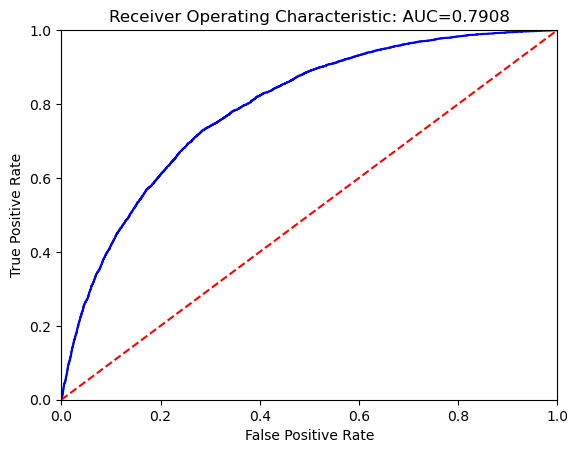

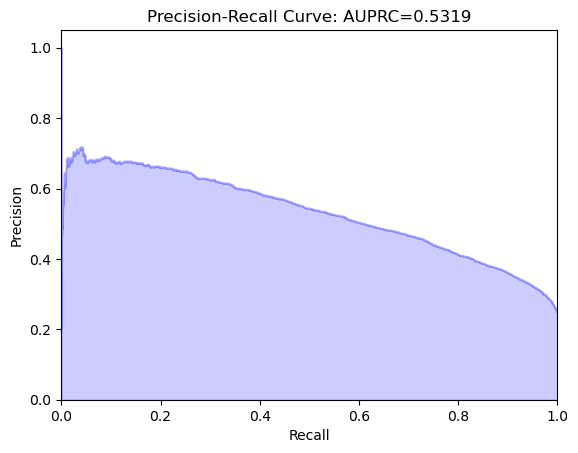

Accuracy: 0.783819


In [23]:
print("Logistic Regression (DIR + CV):")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=random_seed))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs', 'liblinear']
}

train_df = X_train.copy()
train_df['label'] = y_train.values

train_aif = StandardDataset(
    df=train_df,
    label_name='label',
    favorable_classes=[1],
    protected_attribute_names=['gender'],
    privileged_classes=[[1]]
)

dir = DisparateImpactRemover(repair_level=1.0)
train_repaired = dir.fit_transform(train_aif)

try:
    X_tr_repaired = pd.DataFrame(train_repaired.features, columns=X_train.columns, index=X_train.index)
except Exception:
    X_tr_repaired = pd.DataFrame(train_repaired.features)
X_tr_repaired = X_tr_repaired.astype(float)
y_tr_repaired = train_repaired.labels.ravel()

X_test = X_test.astype(float)

print("Running hyperparameter tuning (DIR-repaired train)...")
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid.fit(X_tr_repaired, y_tr_repaired)
runtime = time.time() - start

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

scaler_fitted = best_model.named_steps.get('scaler', None)
if scaler_fitted is not None:
    X_test_sca = pd.DataFrame(scaler_fitted.transform(X_test), columns=X_test.columns, index=X_test.index)
else:
    X_test_sca = X_test.copy()

probs = best_model.predict_proba(X_test)
y_pred_lr = best_model.predict(X_test)

result = PlotROCCurve(probs[:, 1], y_test, ci=confidence_interval, random_seed=random_seed)
results = ["LR"]
results.extend(result)
results.append(runtime)

acc = accuracy_score(y_test, y_pred_lr)
results.append(acc)
result_list.append(results)

print(f"Accuracy: {acc:.6f}")

In [26]:
probs = best_model.predict_proba(X_test_sca) 
y_pred = (probs[:, 1] >= 0.247).astype(int)

In [27]:
def _clean_series(s):
    s = s.fillna('').astype(str).str.strip()
    invalid = {'', 'nan', 'unknown', 'unable to obtain', 'declines to state'}
    return s, ~s.str.lower().isin(invalid)

def prepare_group_fair_df(attr_name, mapping=None):
    raw = df_test[attr_name]
    s_clean, valid_mask = _clean_series(raw)
    idx = valid_mask[valid_mask].index if isinstance(valid_mask, pd.Series) else valid_mask
    group_vals = s_clean[valid_mask]
    if mapping:
        group_mapped = group_vals.str.upper().map(mapping)
    else:
        group_mapped = group_vals
    fair_df = pd.DataFrame({
        'y_true': y_test[valid_mask],
        'y_pred': y_pred[valid_mask],
        'y_score': probs[:, 1][valid_mask],
        attr_name: group_mapped
    })
    return fair_df, group_mapped, valid_mask

def print_bootstrap_group_metrics(ci_df, group_label_to_id, heading=None):
    if heading:
        print(f"\n{heading}")
    for label, gid in group_label_to_id.items():
        group_metrics = ci_df[ci_df['Group'] == gid]
        print(f"\n{label}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")

In [28]:
gender_map = {'F': 0, 'M': 1}
fair_df, gender_grouped, valid_mask_gender = prepare_group_fair_df('gender', mapping=gender_map)

ci_df_gender = bootstrap_fairness_metric_ci(
    df=fair_df,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='gender',
    B=1000,
    random_seed=42
)

print_bootstrap_group_metrics(
    ci_df_gender,
    group_label_to_id={'Female': 0, 'Male': 1},
    heading="=== Logistic Regression Per-Gender Metrics (Mean + 95% CI) ==="
)


=== Logistic Regression Per-Gender Metrics (Mean + 95% CI) ===

Female:
accuracy         Mean = 0.79210, CI = (0.78509, 0.79886)
precision        Mean = 0.56658, CI = (0.53852, 0.59531)
recall           Mean = 0.24790, CI = (0.23145, 0.26391)
f1               Mean = 0.34484, CI = (0.32552, 0.36387)
specificity      Mean = 0.94628, CI = (0.94178, 0.95067)
fpr              Mean = 0.05372, CI = (0.04933, 0.05822)
fnr              Mean = 0.75210, CI = (0.73609, 0.76855)
selection_rate   Mean = 0.09659, CI = (0.09152, 0.10173)
auc              Mean = 0.75490, CI = (0.74531, 0.76506)

Male:
accuracy         Mean = 0.74598, CI = (0.73761, 0.75437)
precision        Mean = 0.57660, CI = (0.55344, 0.60012)
recall           Mean = 0.31791, CI = (0.30125, 0.33378)
f1               Mean = 0.40980, CI = (0.39270, 0.42702)
specificity      Mean = 0.91036, CI = (0.90422, 0.91658)
fpr              Mean = 0.08964, CI = (0.08342, 0.09578)
fnr              Mean = 0.68209, CI = (0.66622, 0.69875)
selectio

In [29]:
def add_error_columns(ci_df, mean_col='Mean', lower_col='CI_lower', upper_col='CI_upper'):
    ci_df = ci_df.copy()
    ci_df['Error Lower'] = ci_df[mean_col] - ci_df[lower_col]
    ci_df['Error Upper'] = ci_df[upper_col] - ci_df[mean_col]
    return ci_df

def plot_group_ci(ci_df, group_col='Group', mean_col='Mean',
                  err_low='Error Lower', err_up='Error Upper',
                  cmap='lightcoral', figsize_per_metric=(4, 4), title=None):
    metrics = ci_df['Metric'].unique()
    n = len(metrics)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_metric[0] * n, figsize_per_metric[1]), squeeze=False)
    axes = axes.ravel()
    for i, metric in enumerate(metrics):
        ax = axes[i]
        subset = ci_df[ci_df['Metric'] == metric].sort_values(by=group_col)
        groups = subset[group_col].astype(str)
        means = subset[mean_col].to_numpy(dtype=float)
        lower = subset[err_low].to_numpy(dtype=float)
        upper = subset[err_up].to_numpy(dtype=float)
        yerr = np.vstack([lower, upper])
        x = np.arange(len(groups))
        ax.bar(x, means, yerr=yerr, capsize=6, color=cmap)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=30, ha='right')
        ax.set_title(metric, fontsize=11)
        ax.set_xlabel(group_col)
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_subgroup_roc(fair_df, group_col, label_map=None, colors=None, figsize=(8,6), title=None):
    """
    Plots ROC curves per subgroup. label_map maps group values -> display labels.
    Skips groups with <2 classes in y_true.
    """
    groups = sorted(fair_df[group_col].unique(), key=lambda x: (str(x)))
    plt.figure(figsize=figsize)
    any_plotted = False
    for i, g in enumerate(groups):
        group_df = fair_df[fair_df[group_col] == g]
        if group_df.empty or group_df['y_true'].nunique() < 2:
            continue
        try:
            fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
            auc = roc_auc_score(group_df['y_true'], group_df['y_score'])
        except ValueError:
            continue
        label = label_map.get(g, str(g)) if label_map else str(g)
        color = None
        if colors:
            color = colors.get(g) if isinstance(colors, dict) else colors[i % len(colors)]
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)
        any_plotted = True
    plt.plot([0,1],[0,1],'k--', linewidth=0.8)
    if title:
        plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    if any_plotted:
        plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

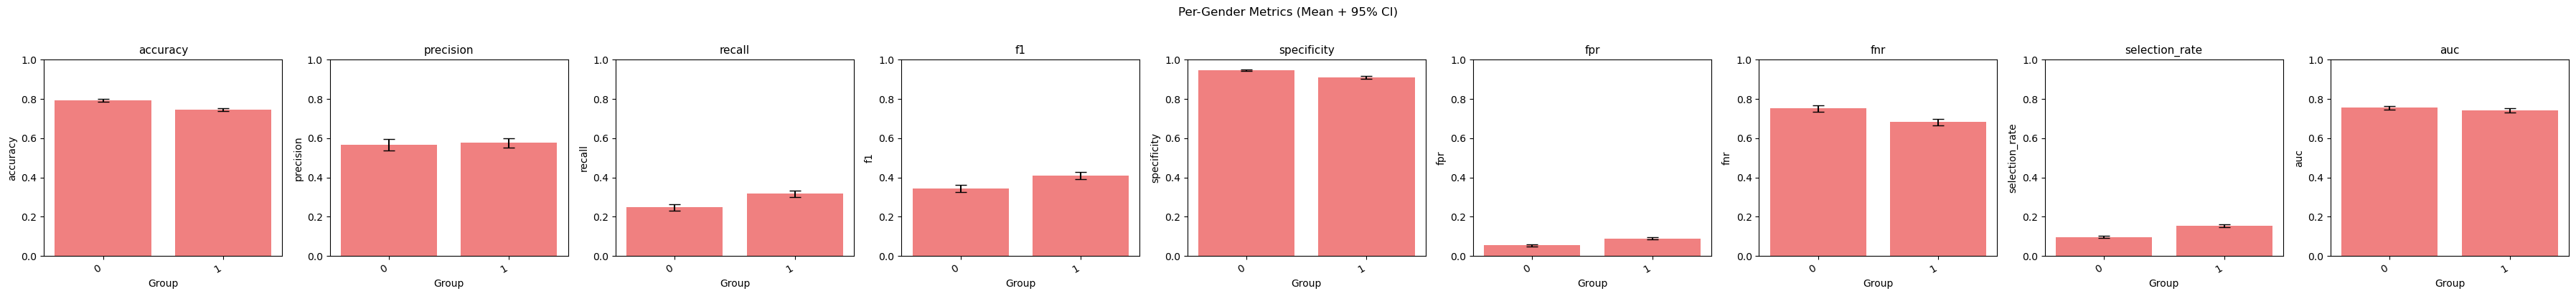

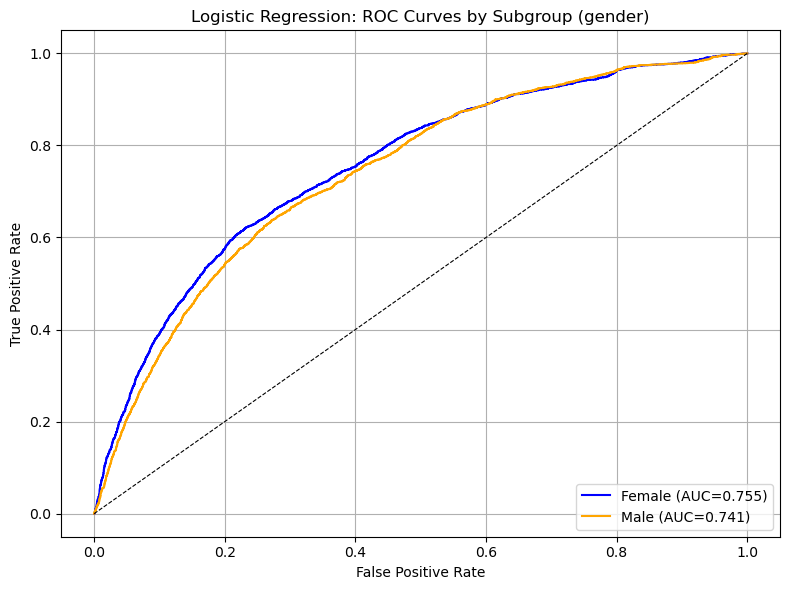

In [30]:
ci_df_gender = add_error_columns(ci_df_gender)

plot_group_ci(
    ci_df_gender,
    group_col='Group',
    mean_col='Mean',
    err_low='Error Lower',
    err_up='Error Upper',
    cmap='lightcoral',
    title='Per-Gender Metrics (Mean + 95% CI)'
)

label_map = {0: 'Female', 1: 'Male'}
plot_subgroup_roc(
    fair_df,
    group_col='gender',
    label_map=label_map,
    colors={0: 'blue', 1: 'orange'},
    title='Logistic Regression: ROC Curves by Subgroup (gender)'
)

Race and Ethnicity Mapping

In [31]:
race_raw = df_test['race'].astype(str)
ethnicity_raw = df_test['ethnicity'].astype(str)

valid_mask_race_ethnicity = (
    race_raw.notna() &
    ethnicity_raw.notna() &
    (race_raw.str.strip() != '') &
    (ethnicity_raw.str.strip() != '') &
    (race_raw != 'nan') &
    (ethnicity_raw != 'nan') &
    (~race_raw.str.lower().isin(['unknown', 'unable to obtain', 'declines to state'])) &
    (~ethnicity_raw.str.lower().isin(['unknown', 'unable to obtain', 'declines to state']))
)

y_test_race_ethnicity = y_test[valid_mask_race_ethnicity]
y_pred_race_ethnicity = y_pred[valid_mask_race_ethnicity]
y_score_race_ethnicity = probs[:, 1][valid_mask_race_ethnicity]

race_clean = race_raw[valid_mask_race_ethnicity].str.strip()
ethnicity_clean = ethnicity_raw[valid_mask_race_ethnicity].str.strip()

print("Unique race values:")
print(sorted(race_clean.unique()))
print("\nUnique ethnicity values:")
print(sorted(ethnicity_clean.unique()))

def map_race_ethnicity(race_val, ethnicity_val):
    race_str = str(race_val).strip()
    ethnicity_str = str(ethnicity_val).strip()
    
    # Hispanic/Latino takes priority regardless of race
    if 'Hispanic/Latino' in ethnicity_str:
        return 'Hispanic/Latino'
    # Then map by race
    elif 'White' in race_str:
        return 'White'
    elif 'Asian' in race_str:
        return 'Asian'
    elif 'Black or African American' in race_str:
        return 'Black or African American'
    else:
        return 'Other'

Unique race values:
['American Indian or Alaska Native', 'Asian', 'Black or African American', 'Native Hawaiian or Other Pacific Islander', 'Other', 'White']

Unique ethnicity values:
['Hispanic/Latino', 'Non-Hispanic/Non-Latino']


In [32]:
race_ethnicity_grouped = [map_race_ethnicity(r, e) for r, e in zip(race_clean, ethnicity_clean)]

fair_df_race_ethnicity = pd.DataFrame({
    'y_true': y_test_race_ethnicity,
    'y_pred': y_pred_race_ethnicity,
    'y_score': y_score_race_ethnicity,
    'race_ethnicity': race_ethnicity_grouped
})

print("\nRace/Ethnicity group distribution:")
print(fair_df_race_ethnicity['race_ethnicity'].value_counts())

ci_df_race_ethnicity = bootstrap_fairness_metric_ci(
    df=fair_df_race_ethnicity,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='race_ethnicity',
    B=1000,
    random_seed=42
)

print("\n=== Logistic Regression Per-Race/Ethnicity Metrics (Mean + 95% CI) ===")
for group in ['Asian', 'Black or African American', 'Hispanic/Latino', 'Other', 'White']:
    if group in ci_df_race_ethnicity['Group'].values:
        group_metrics = ci_df_race_ethnicity[ci_df_race_ethnicity['Group'] == group]
        print(f"\n{group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


Race/Ethnicity group distribution:
race_ethnicity
White                        8783
Hispanic/Latino              6450
Asian                        3856
Other                        2808
Black or African American    1462
Name: count, dtype: int64

=== Logistic Regression Per-Race/Ethnicity Metrics (Mean + 95% CI) ===

Asian:
accuracy         Mean = 0.75543, CI = (0.74175, 0.76903)
precision        Mean = 0.63320, CI = (0.59165, 0.67824)
recall           Mean = 0.30602, CI = (0.28116, 0.33157)
f1               Mean = 0.41248, CI = (0.38398, 0.44110)
specificity      Mean = 0.93080, CI = (0.92097, 0.94000)
fpr              Mean = 0.06920, CI = (0.06000, 0.07903)
fnr              Mean = 0.69398, CI = (0.66843, 0.71884)
selection_rate   Mean = 0.13567, CI = (0.12560, 0.14650)
auc              Mean = 0.76688, CI = (0.74899, 0.78376)

Black or African American:
accuracy         Mean = 0.78040, CI = (0.75847, 0.80030)
precision        Mean = 0.54438, CI = (0.47618, 0.60644)
recall           M

/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

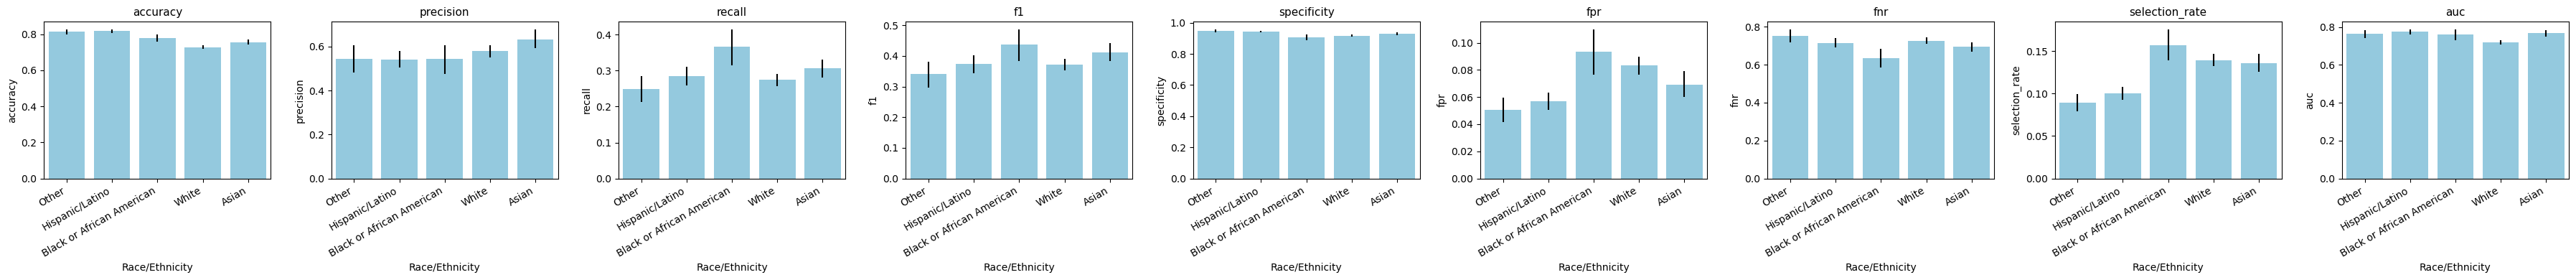

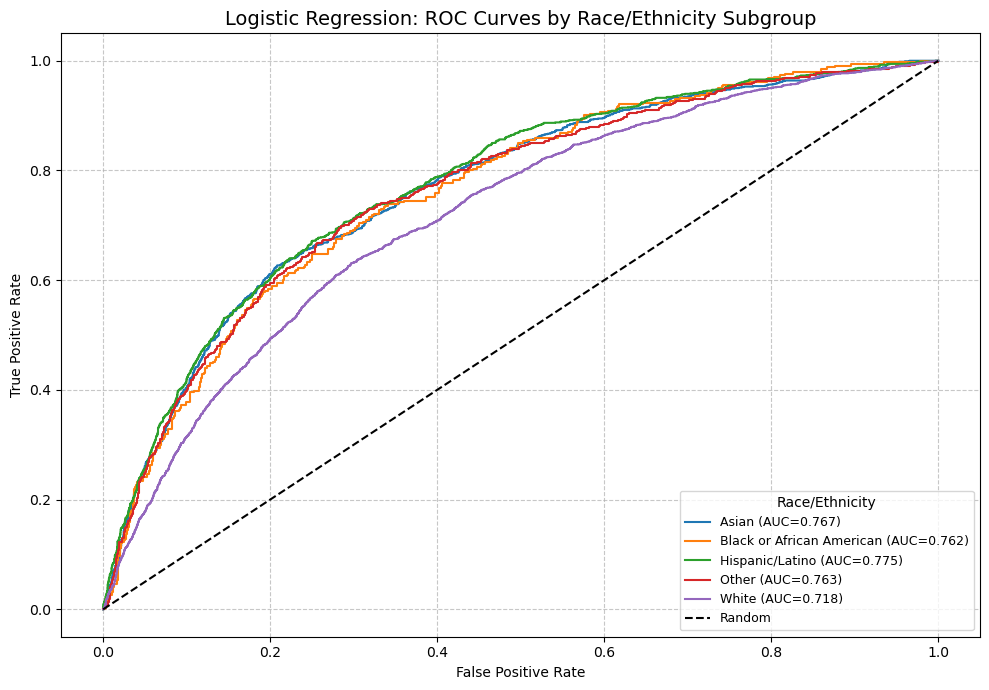

In [33]:
ci_df_race_ethnicity['Error Lower'] = ci_df_race_ethnicity['Mean'] - ci_df_race_ethnicity['CI_lower']
ci_df_race_ethnicity['Error Upper'] = ci_df_race_ethnicity['CI_upper'] - ci_df_race_ethnicity['Mean']

metrics = ci_df_race_ethnicity['Metric'].unique()
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    subset = ci_df_race_ethnicity[ci_df_race_ethnicity['Metric'] == metric]

    sns.barplot(
        data=subset,
        x='Group',
        y='Mean',
        yerr=[subset['Error Lower'], subset['Error Upper']],
        capsize=0.2,
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'{metric}', fontsize=11)
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

race_ethnicity_groups = fair_df_race_ethnicity['race_ethnicity'].unique()

plt.figure(figsize=(10, 7))

for group in sorted(race_ethnicity_groups):
    group_df = fair_df_race_ethnicity[fair_df_race_ethnicity['race_ethnicity'] == group]

    fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
    auc = roc_auc_score(group_df['y_true'], group_df['y_score'])

    plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Logistic Regression: ROC Curves by Race/Ethnicity Subgroup', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(title='Race/Ethnicity', loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Age Group

In [34]:
def plot_grouped_metrics_ci(ci_df, group_col='Group', mean_col='Mean', err_low='Error Lower', err_up='Error Upper', cmap='cornflowerblue'):
    metrics = ci_df['Metric'].unique()
    n_metrics = len(metrics)
    if n_metrics == 0:
        return
    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), squeeze=False)
    axes = axes.ravel()
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        subset = ci_df[ci_df['Metric'] == metric].sort_values(by=group_col)
        groups = subset[group_col].astype(str).tolist()
        means = subset[mean_col].to_numpy(dtype=float)
        err_lower = subset[err_low].to_numpy(dtype=float)
        err_upper = subset[err_up].to_numpy(dtype=float)
        # convert to symmetric matplotlib yerr format
        yerr = np.vstack([err_lower, err_upper])
        x = np.arange(len(groups))
        ax.bar(x, means, yerr=yerr, capsize=6, color=cmap)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=30, ha='right')
        ax.set_title(metric, fontsize=11)
        ax.set_xlabel(group_col)
        ax.set_ylabel('Value')
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def plot_group_roc_curves(fair_df, group_col, order=None, figsize=(10,7), title='ROC Curves by Group'):
    groups = fair_df[group_col].unique()
    if order is not None:
        # keep only groups present in data and in the supplied order
        groups = [g for g in order if g in fair_df[group_col].unique()]
    plt.figure(figsize=figsize)
    any_plotted = False
    for group in groups:
        group_df = fair_df[fair_df[group_col] == group]
        if group_df.empty:
            continue
        if group_df['y_true'].nunique() < 2:
            print(f"Skipping {group}: only one class present.")
            continue
        fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
        auc = roc_auc_score(group_df['y_true'], group_df['y_score'])
        plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')
        any_plotted = True
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title(title, fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(title=group_col, loc='lower right', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.7)
    if any_plotted:
        plt.tight_layout()
    plt.show()

In [35]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 150]
age_labels = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']

age_grouped = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=True)
valid_mask = age_grouped.notna()

y_test_age = y_test[valid_mask]
y_pred_age = y_pred[valid_mask]
y_score_age = probs[:, 1][valid_mask]
age_grouped_clean = age_grouped[valid_mask]

fair_df_age = pd.DataFrame({
    'y_true': y_test_age,
    'y_pred': y_pred_age,
    'y_score': y_score_age,
    'age_group': age_grouped_clean
})

ci_df_age = bootstrap_fairness_metric_ci(
    df=fair_df_age,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='age_group',
    B=1000,
    random_seed=42
)

print("\n=== Logistic Regression Per-Age Group Metrics(Mean + 95% CI) ===")
for group in age_labels:
    if group in ci_df_age['Group'].values:
        group_metrics = ci_df_age[ci_df_age['Group'] == group]
        print(f"\nAge Group {group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")



=== Logistic Regression Per-Age Group Metrics(Mean + 95% CI) ===

Age Group 18–24:
accuracy         Mean = 0.89303, CI = (0.87848, 0.90708)
precision        Mean = 0.57677, CI = (0.43182, 0.71111)
recall           Mean = 0.13720, CI = (0.09216, 0.18751)
f1               Mean = 0.22103, CI = (0.15584, 0.28986)
specificity      Mean = 0.98741, CI = (0.98186, 0.99241)
fpr              Mean = 0.01259, CI = (0.00759, 0.01814)
fnr              Mean = 0.86280, CI = (0.81249, 0.90784)
selection_rate   Mean = 0.02642, CI = (0.01923, 0.03370)
auc              Mean = 0.80262, CI = (0.77319, 0.83197)

Age Group 25–34:
accuracy         Mean = 0.88488, CI = (0.87470, 0.89468)
precision        Mean = 0.55717, CI = (0.48500, 0.63415)
recall           Mean = 0.21262, CI = (0.17459, 0.25000)
f1               Mean = 0.30745, CI = (0.25926, 0.35260)
specificity      Mean = 0.97688, CI = (0.97176, 0.98171)
fpr              Mean = 0.02312, CI = (0.01829, 0.02824)
fnr              Mean = 0.78738, CI = (0.75

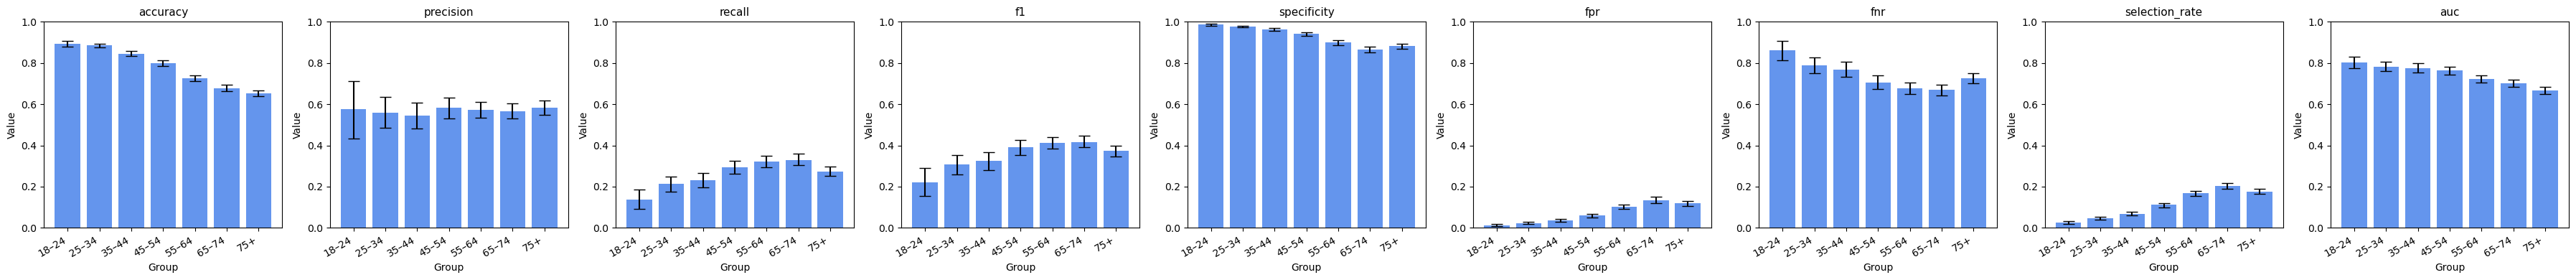

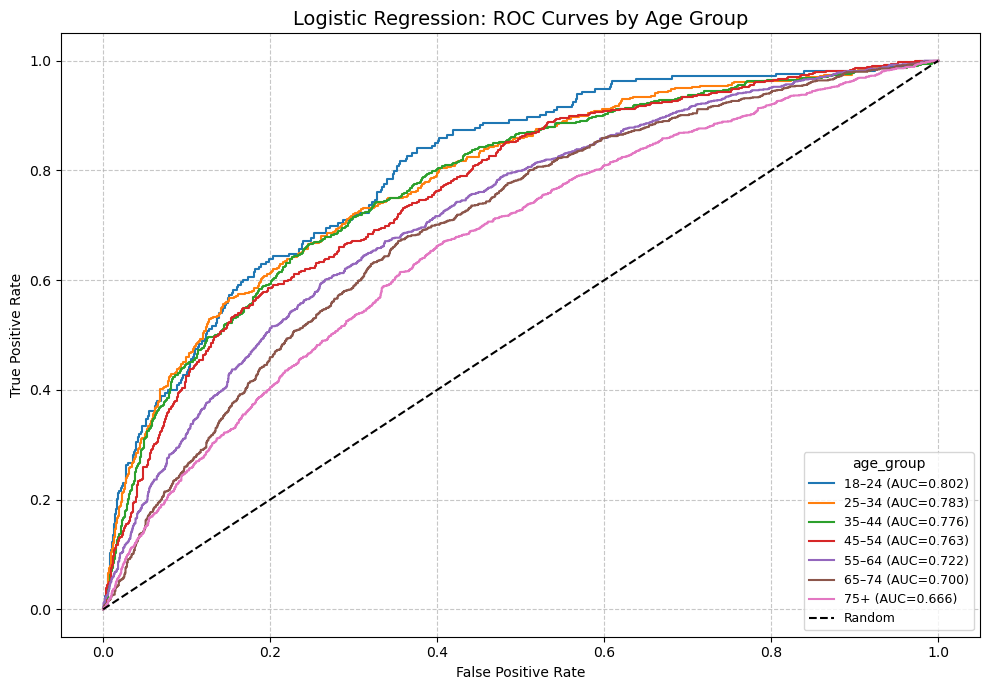

In [36]:
ci_df_age['Error Lower'] = ci_df_age['Mean'] - ci_df_age['CI_lower']
ci_df_age['Error Upper'] = ci_df_age['CI_upper'] - ci_df_age['Mean']

age_labels_ordered = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
ci_df_age['Group'] = pd.Categorical(ci_df_age['Group'], categories=age_labels_ordered, ordered=True)

plot_grouped_metrics_ci(ci_df_age, group_col='Group', cmap='cornflowerblue')
plot_group_roc_curves(fair_df_age, group_col='age_group', order=age_labels_ordered, title='Logistic Regression: ROC Curves by Age Group')

# Random Forest

RandomForest (DIR + CV):
Running RF hyperparameter tuning (on DIR-repaired train)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/xinniemai/miniconda3/envs/ds6001summer2025/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
AUC: 0.80458241777318
AUPRC: 0.5626745830706035
Sensitivity: 0.7369051694625128
Specificity: 0.7211128561812878
Score thresold: 0.2707239604316931
2.5 97.5


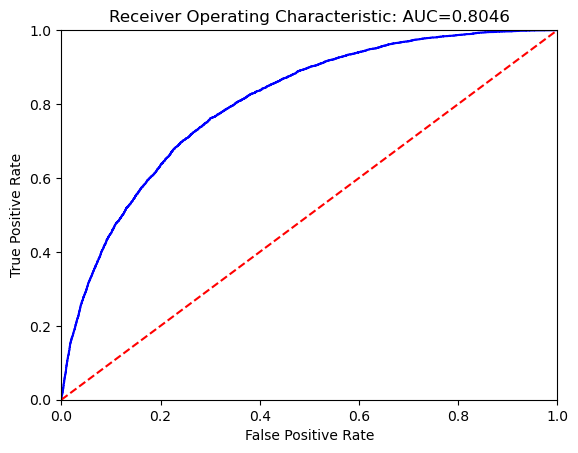

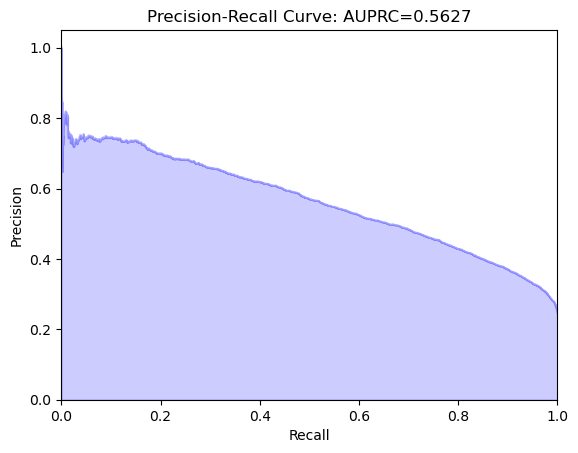

[0.09233712 0.01005243 0.01205784 0.01715397 0.02696696 0.00508123
 0.02421641 0.04425361 0.00091517 0.0019643  0.00218511 0.04715085
 0.07889768 0.04417968 0.04491155 0.0637643  0.05926168 0.07837954
 0.00615873 0.00986457 0.00420904 0.01610777 0.00276093 0.00262184
 0.00564845 0.0064121  0.00214529 0.00318075 0.00945561 0.02126701
 0.0086448  0.00664254 0.00308371 0.00743541 0.0041711  0.00213931
 0.00807012 0.00820114 0.00445761 0.00194808 0.01749572 0.04082439
 0.00637795 0.0122325  0.00072883 0.01160983 0.00568849 0.00757387
 0.01302334 0.00237447 0.00639876 0.00623649 0.0032356  0.00645245
 0.00628469 0.00663285 0.01864827 0.00343118 0.0056055  0.00541264
 0.00442385 0.00311528 0.0078377 ]
Accuracy: 0.790114


In [37]:
print("RandomForest (DIR + CV):")

train_df = X_train.copy()
train_df['label'] = y_train.values
train_aif = StandardDataset(
    df=train_df,
    label_name='label',
    favorable_classes=[1],
    protected_attribute_names=['gender'],
    privileged_classes=[[1]]
)

dir = DisparateImpactRemover(repair_level=1.0)
train_repaired = dir.fit_transform(train_aif)

try:
    X_tr_repaired = pd.DataFrame(train_repaired.features, columns=X_train.columns, index=X_train.index)
except Exception:
    X_tr_repaired = pd.DataFrame(train_repaired.features)
X_tr_repaired = X_tr_repaired.astype(float)
y_tr_repaired = train_repaired.labels.ravel()

rf = RandomForestClassifier(random_state=random_seed, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

print("Running RF hyperparameter tuning (on DIR-repaired train)...")
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_rf.fit(X_tr_repaired, y_tr_repaired)
runtime = time.time() - start

best_model = grid_rf.best_estimator_
print("Best RF params:", grid_rf.best_params_)

probs = best_model.predict_proba(X_test)
result = PlotROCCurve(probs[:, 1], y_test, ci=confidence_interval, random_seed=random_seed)

importances = best_model.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

y_pred_rf = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred_rf)
results.append(acc)

print(f"Accuracy: {acc:.6f}")

In [38]:
probs = best_model.predict_proba(X_test)
y_pred = (probs[:, 1] >= 0.27).astype(int)

In [39]:
gender_map = {'F': 0, 'M': 1}
fair_df, gender_grouped, valid_mask_gender = prepare_group_fair_df('gender', mapping=gender_map)

ci_df_gender = bootstrap_fairness_metric_ci(
    df=fair_df,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='gender',
    B=1000,
    random_seed=42
)

print_bootstrap_group_metrics(
    ci_df_gender,
    group_label_to_id={'Female': 0, 'Male': 1},
    heading="=== Random Forest Per-Gender Metrics (Mean + 95% CI) ==="
)


=== Random Forest Per-Gender Metrics (Mean + 95% CI) ===

Female:
accuracy         Mean = 0.74343, CI = (0.73593, 0.75076)
precision        Mean = 0.44933, CI = (0.43426, 0.46475)
recall           Mean = 0.71912, CI = (0.70222, 0.73616)
f1               Mean = 0.55304, CI = (0.53878, 0.56694)
specificity      Mean = 0.75031, CI = (0.74188, 0.75851)
fpr              Mean = 0.24969, CI = (0.24149, 0.25812)
fnr              Mean = 0.28088, CI = (0.26384, 0.29778)
selection_rate   Mean = 0.35333, CI = (0.34527, 0.36141)
auc              Mean = 0.80949, CI = (0.80057, 0.81811)

Male:
accuracy         Mean = 0.70199, CI = (0.69364, 0.71046)
precision        Mean = 0.47660, CI = (0.46238, 0.49128)
recall           Mean = 0.75435, CI = (0.73959, 0.76869)
f1               Mean = 0.58411, CI = (0.57024, 0.59735)
specificity      Mean = 0.68188, CI = (0.67192, 0.69210)
fpr              Mean = 0.31812, CI = (0.30790, 0.32808)
fnr              Mean = 0.24565, CI = (0.23131, 0.26041)
selection_rate

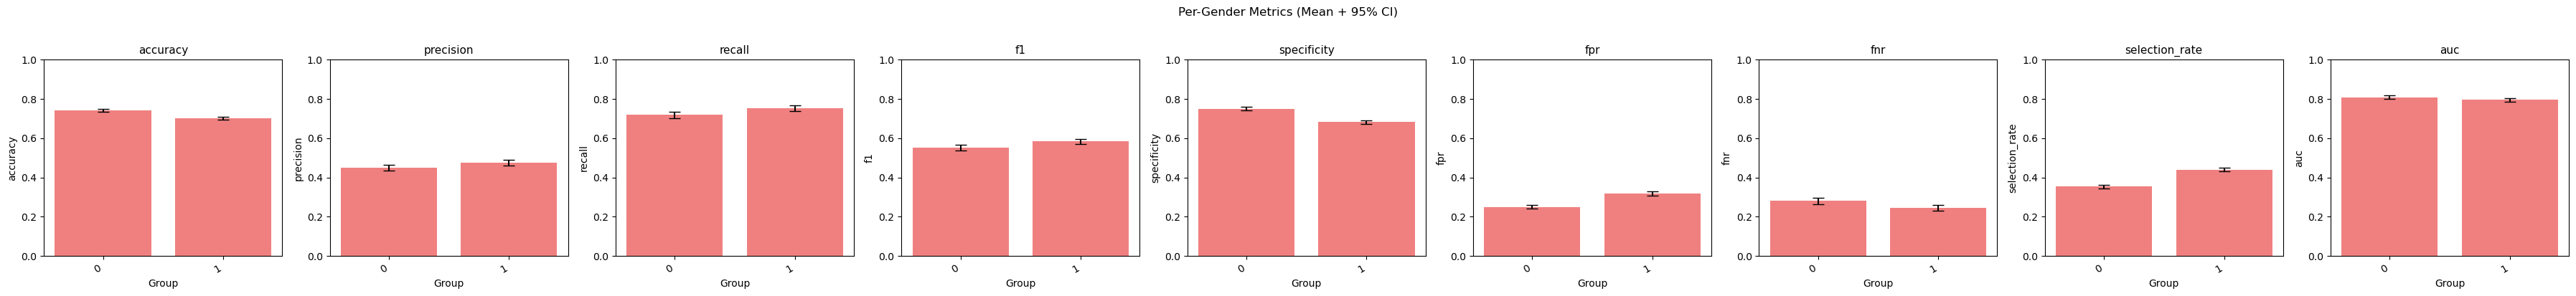

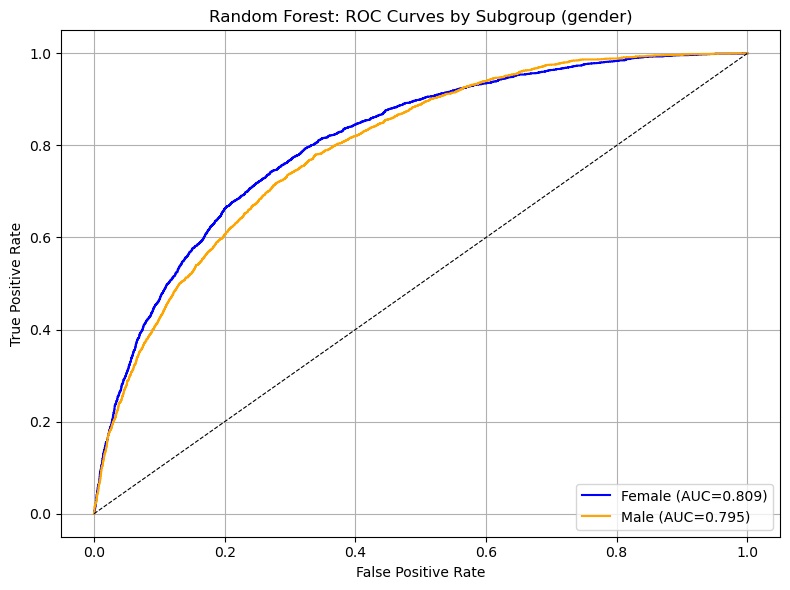

In [40]:
ci_df_gender = add_error_columns(ci_df_gender)

plot_group_ci(
    ci_df_gender,
    group_col='Group',
    mean_col='Mean',
    err_low='Error Lower',
    err_up='Error Upper',
    cmap='lightcoral',
    title='Per-Gender Metrics (Mean + 95% CI)'
)

label_map = {0: 'Female', 1: 'Male'}
plot_subgroup_roc(
    fair_df,
    group_col='gender',
    label_map=label_map,
    colors={0: 'blue', 1: 'orange'},
    title='Random Forest: ROC Curves by Subgroup (gender)'
)

In [41]:
race_ethnicity_grouped = [map_race_ethnicity(r, e) for r, e in zip(race_clean, ethnicity_clean)]

fair_df_race_ethnicity = pd.DataFrame({
    'y_true': y_test_race_ethnicity,
    'y_pred': y_pred_race_ethnicity,
    'y_score': y_score_race_ethnicity,
    'race_ethnicity': race_ethnicity_grouped
})

ci_df_race_ethnicity = bootstrap_fairness_metric_ci(
    df=fair_df_race_ethnicity,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='race_ethnicity',
    B=1000,
    random_seed=42
)

print("\n=== Random Forest Per-Race/Ethnicity Metrics (Mean + 95% CI) ===")
for group in ['Asian', 'Black or African American', 'Hispanic/Latino', 'Other', 'White']:
    if group in ci_df_race_ethnicity['Group'].values:
        group_metrics = ci_df_race_ethnicity[ci_df_race_ethnicity['Group'] == group]
        print(f"\n{group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


=== Random Forest Per-Race/Ethnicity Metrics (Mean + 95% CI) ===

Asian:
accuracy         Mean = 0.75543, CI = (0.74175, 0.76903)
precision        Mean = 0.63320, CI = (0.59165, 0.67824)
recall           Mean = 0.30602, CI = (0.28116, 0.33157)
f1               Mean = 0.41248, CI = (0.38398, 0.44110)
specificity      Mean = 0.93080, CI = (0.92097, 0.94000)
fpr              Mean = 0.06920, CI = (0.06000, 0.07903)
fnr              Mean = 0.69398, CI = (0.66843, 0.71884)
selection_rate   Mean = 0.13567, CI = (0.12560, 0.14650)
auc              Mean = 0.76688, CI = (0.74899, 0.78376)

Black or African American:
accuracy         Mean = 0.78040, CI = (0.75847, 0.80030)
precision        Mean = 0.54438, CI = (0.47618, 0.60644)
recall           Mean = 0.36646, CI = (0.31490, 0.41499)
f1               Mean = 0.43756, CI = (0.38321, 0.48710)
specificity      Mean = 0.90655, CI = (0.89005, 0.92361)
fpr              Mean = 0.09345, CI = (0.07639, 0.10995)
fnr              Mean = 0.63354, CI = (0.58

/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_81720/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

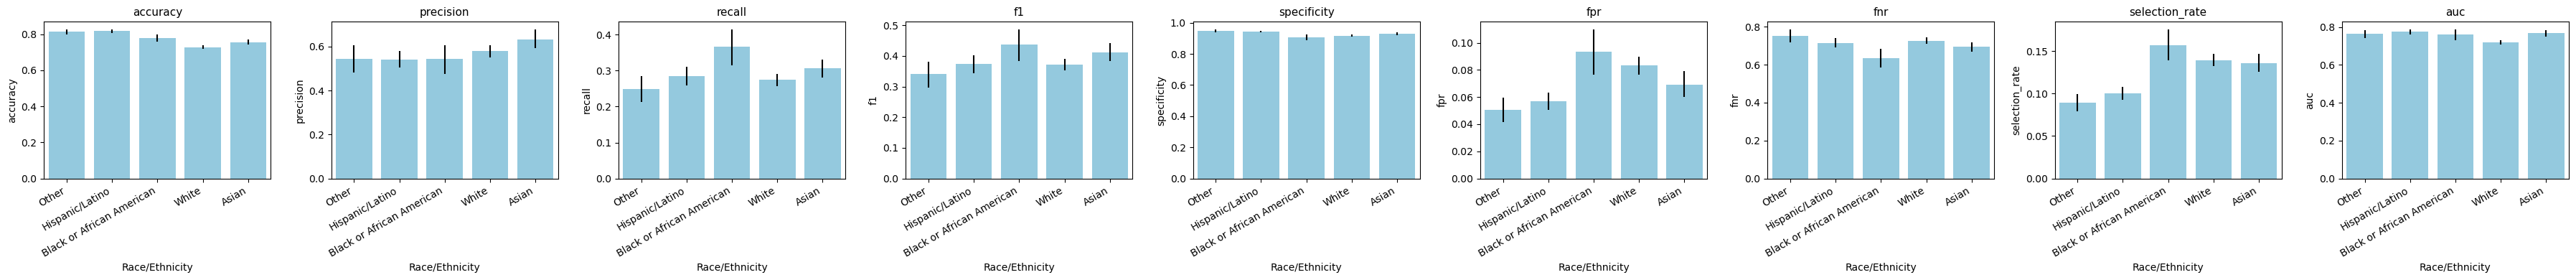

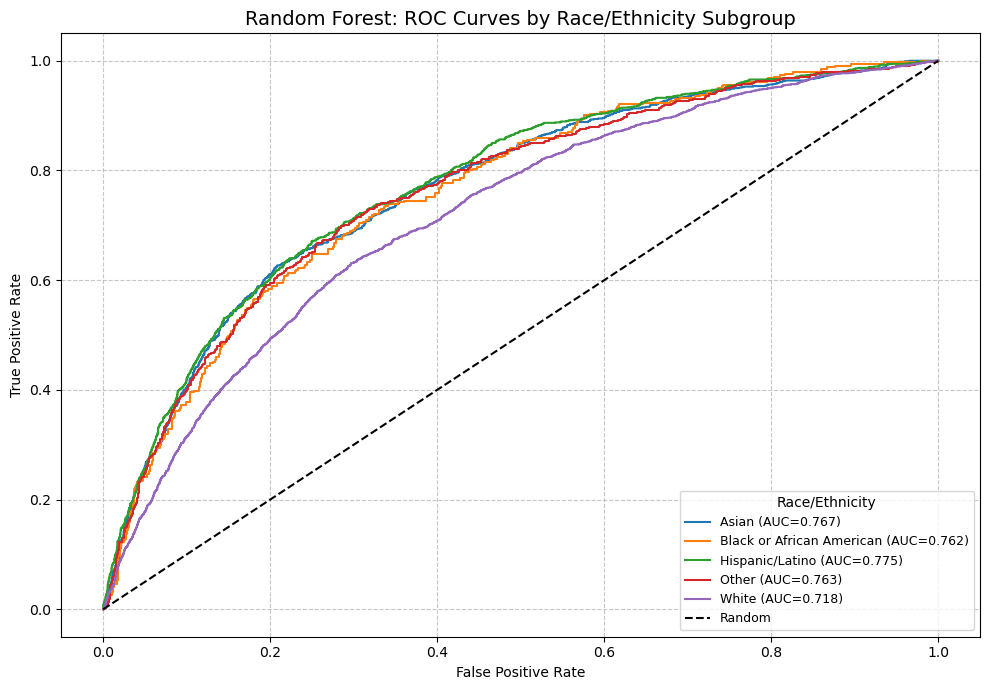

In [42]:
ci_df_race_ethnicity['Error Lower'] = ci_df_race_ethnicity['Mean'] - ci_df_race_ethnicity['CI_lower']
ci_df_race_ethnicity['Error Upper'] = ci_df_race_ethnicity['CI_upper'] - ci_df_race_ethnicity['Mean']

metrics = ci_df_race_ethnicity['Metric'].unique()
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    subset = ci_df_race_ethnicity[ci_df_race_ethnicity['Metric'] == metric]

    sns.barplot(
        data=subset,
        x='Group',
        y='Mean',
        yerr=[subset['Error Lower'], subset['Error Upper']],
        capsize=0.2,
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'{metric}', fontsize=11)
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

race_ethnicity_groups = fair_df_race_ethnicity['race_ethnicity'].unique()

plt.figure(figsize=(10, 7))

for group in sorted(race_ethnicity_groups):
    group_df = fair_df_race_ethnicity[fair_df_race_ethnicity['race_ethnicity'] == group]

    fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
    auc = roc_auc_score(group_df['y_true'], group_df['y_score'])

    plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Random Forest: ROC Curves by Race/Ethnicity Subgroup', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(title='Race/Ethnicity', loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [43]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 150]
age_labels = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']

age_grouped = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=True)
valid_mask = age_grouped.notna()

y_test_age = y_test[valid_mask]
y_pred_age = y_pred[valid_mask]
y_score_age = probs[:, 1][valid_mask]
age_grouped_clean = age_grouped[valid_mask]

fair_df_age = pd.DataFrame({
    'y_true': y_test_age,
    'y_pred': y_pred_age,
    'y_score': y_score_age,
    'age_group': age_grouped_clean
})

ci_df_age = bootstrap_fairness_metric_ci(
    df=fair_df_age,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='age_group',
    B=1000,
    random_seed=42
)

print("\n=== Random Forest Per-Age Group Metrics(Mean + 95% CI) ===")
for group in age_labels:
    if group in ci_df_age['Group'].values:
        group_metrics = ci_df_age[ci_df_age['Group'] == group]
        print(f"\nAge Group {group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")



=== Random Forest Per-Age Group Metrics(Mean + 95% CI) ===

Age Group 18–24:
accuracy         Mean = 0.87257, CI = (0.85685, 0.88669)
precision        Mean = 0.42321, CI = (0.35748, 0.49065)
recall           Mean = 0.40686, CI = (0.33918, 0.47144)
f1               Mean = 0.41427, CI = (0.35351, 0.47274)
specificity      Mean = 0.93074, CI = (0.91858, 0.94228)
fpr              Mean = 0.06926, CI = (0.05772, 0.08142)
fnr              Mean = 0.59314, CI = (0.52856, 0.66082)
selection_rate   Mean = 0.10672, CI = (0.09324, 0.12202)
auc              Mean = 0.82755, CI = (0.79991, 0.85278)

Age Group 25–34:
accuracy         Mean = 0.86348, CI = (0.85238, 0.87417)
precision        Mean = 0.44047, CI = (0.39797, 0.48548)
recall           Mean = 0.49620, CI = (0.44731, 0.54260)
f1               Mean = 0.46643, CI = (0.42720, 0.50865)
specificity      Mean = 0.91373, CI = (0.90385, 0.92332)
fpr              Mean = 0.08627, CI = (0.07668, 0.09615)
fnr              Mean = 0.50380, CI = (0.45740, 0

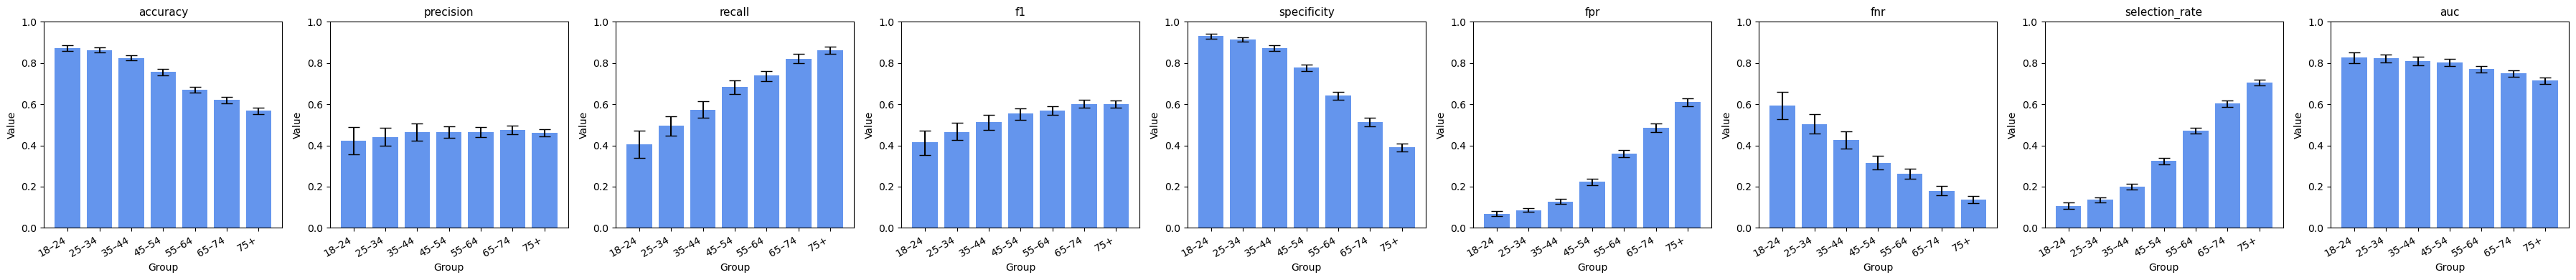

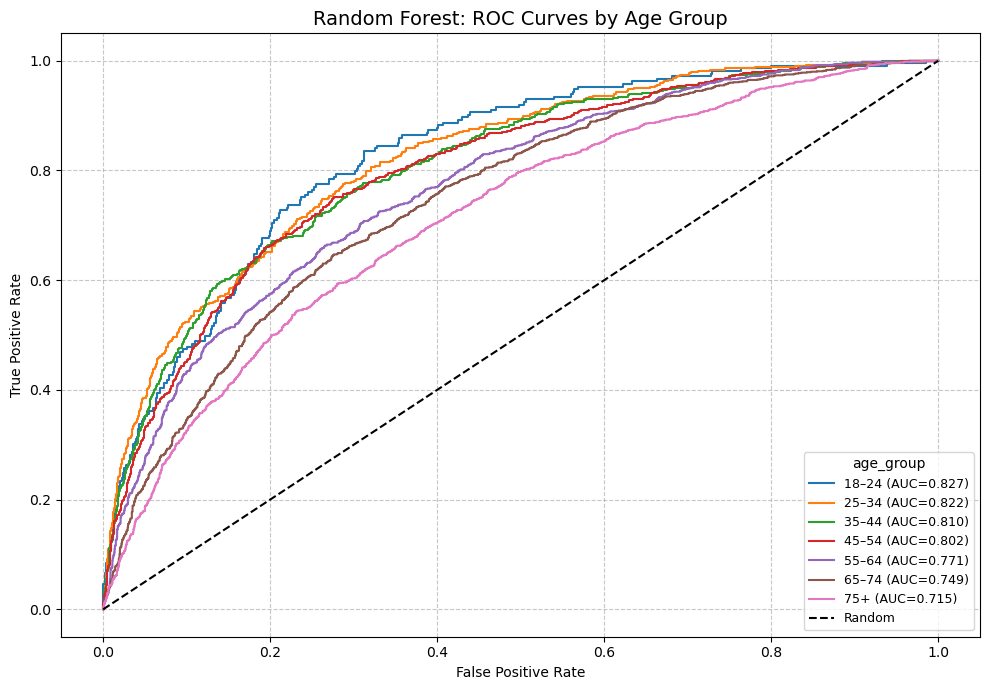

In [44]:
ci_df_age['Error Lower'] = ci_df_age['Mean'] - ci_df_age['CI_lower']
ci_df_age['Error Upper'] = ci_df_age['CI_upper'] - ci_df_age['Mean']

age_labels_ordered = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
ci_df_age['Group'] = pd.Categorical(ci_df_age['Group'], categories=age_labels_ordered, ordered=True)

plot_grouped_metrics_ci(ci_df_age, group_col='Group', cmap='cornflowerblue')
plot_group_roc_curves(fair_df_age, group_col='age_group', order=age_labels_ordered, title='Random Forest: ROC Curves by Age Group')